Column names: ['CandidateID', 'CandidateName', 'Email', 'Password', 'Status', 'images']
Found image for candidate 1: 1234.jpg


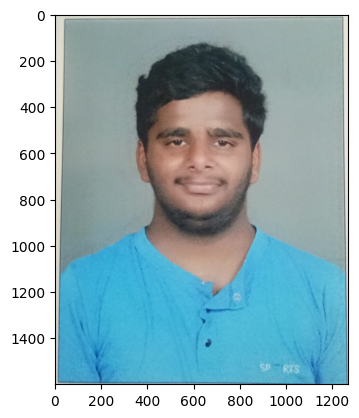

In [10]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Read the candidate.csv file
candidates = pd.read_csv('candidate.csv')

# Print the column names to verify
print("Column names:", candidates.columns.tolist())

# Check if the 'CandidateID' and 'images' columns exist
if 'CandidateID' in candidates.columns and 'images' in candidates.columns:
    # Ask for the candidate ID input
    candidate_id = int(input("Enter the candidate ID: "))

    # Find the image file path for the specified candidate ID
    image_file_path = candidates.loc[candidates['CandidateID'] == candidate_id, 'images'].values[0]

    # Check if the image file exists
    if os.path.exists(image_file_path):
        print(f"Found image for candidate {candidate_id}: {image_file_path}")

        # Display the image
        img = plt.imread(image_file_path)
        plt.imshow(img)
        plt.show()
    else:
        print(f"Error: Image file not found for candidate {candidate_id}: {image_file_path}")
else:
    print("Error: 'CandidateID' or 'images' column not found in the CSV file.")

Found image for candidate 2: harshith.jpg


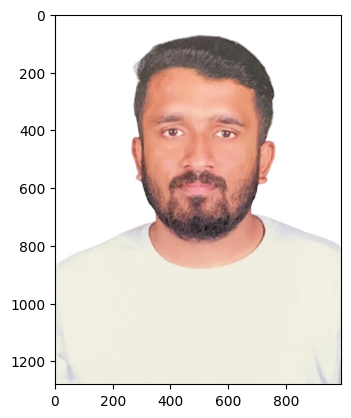

Proctor allocated for candidate ID 2
Proctor Proctor 1 allocated for candidate ID 2
Exam started for candidate ID 2


In [20]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2
import threading

# Load the CSV files into DataFrames
candidates = pd.read_csv('candidate.csv')
proctors = pd.read_csv('Proctor.csv')
proctor_allocation_global = pd.read_csv('Proctor_alocation.csv')

available_proctors = {}
for index, row in proctors.iterrows():
    available_proctors[row['ProctorName']] = {"available": True, "candidate": None}

candidates_dict = {}
for index, row in candidates.iterrows():
    candidates_dict[row['CandidateName']] = {"allocated": False, "proctor": None}

def check_proctor_availability(proctor_id):
    """
    Check if a proctor is available
    """
    proctor_status = proctors.loc[proctors['ProctorID'] == proctor_id, 'Status'].values[0]
    return proctor_status == 'Available'

def allocate_proctor_to_candidate(candidate_id):
    """
    Allocate a proctor to a candidate
    """
    global proctor_allocation_global  # Access the global variable
    available_proctors_list = [proctor for proctor, status in available_proctors.items() if status["available"]]
    if available_proctors_list:
        proctor_name = available_proctors_list[0]
        proctor_id = proctors.loc[proctors['ProctorName'] == proctor_name, 'ProctorID'].values[0]
        new_allocation = pd.DataFrame({'AllocationID': [len(proctor_allocation_global) + 1], 'ProctorID': [proctor_id], 'CandidateID': [candidate_id], 'AllocationTimestamp': [pd.Timestamp.now()]})
        proctor_allocation_global = pd.concat([proctor_allocation_global, new_allocation], ignore_index=True)
        available_proctors[proctor_name]["available"] = False
        available_proctors[proctor_name]["candidate"] = candidate_id
        candidates.loc[candidates['CandidateID'] == candidate_id, 'Status'] = 'In Exam'
        return True
    else:
        return False

def start_exam(candidate_id):
    """
    Start the exam if a proctor is allocated
    """
    allocated_proctor = proctor_allocation_global.loc[proctor_allocation_global['CandidateID'] == candidate_id]
    if not allocated_proctor.empty:
        return True
    else:
        return False

def update_status_after_exam(candidate_id):
    """
    Update the status of proctor and candidate after the exam
    """
    global proctor_allocation_global  # Access the global variable
    allocated_proctor = proctor_allocation_global.loc[proctor_allocation_global['CandidateID'] == candidate_id]
    proctor_id = allocated_proctor['ProctorID'].values[0]
    proctor_name = proctors.loc[proctors['ProctorID'] == proctor_id, 'ProctorName'].values[0]
    available_proctors[proctor_name]["available"] = True
    available_proctors[proctor_name]["candidate"] = None
    candidates.loc[candidates['CandidateID'] == candidate_id, 'Status'] = 'Completed'

def display_webcam_feed(candidate_id):
    """
    Display the webcam feed for a candidate
    """
    cap = cv2.VideoCapture(0)
    while True:
        ret, frame = cap.read()
        cv2.imshow(f'Webcam Feed - {candidate_id}', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

def authenticate_candidate():
    """
    Authenticate the candidate using their ID and password
    """
    candidate_id = int(input("Enter candidate ID: "))
    password = input("Enter password: ")
    if 'Password' in candidates.columns:  # Check if 'Password' column exists
        if candidate_id in candidates['CandidateID'].values and password == candidates.loc[candidates['CandidateID'] == candidate_id, 'Password'].values[0]:
            return candidate_id
        else:
            print("Invalid candidate ID or password")
            return None
    else:
        print("Password column does not exist in the candidates CSV file")
        return None

def display_candidate_image(candidate_id):
    """
    Display the candidate's image
    """
    image_file_path = candidates.loc[candidates['CandidateID'] == candidate_id, 'images'].values[0]
    if os.path.exists(image_file_path):
        print(f"Found image for candidate {candidate_id}: {image_file_path}")
        img = plt.imread(image_file_path)
        plt.imshow(img)
        plt.show()
    else:
        print(f"Error: Image file not found for candidate {candidate_id}: {image_file_path}")

def main():
    candidate_id = authenticate_candidate()
    if candidate_id:
        display_candidate_image(candidate_id)
        if allocate_proctor_to_candidate(candidate_id):
            print("Proctor allocated for candidate ID", candidate_id)
            allocated_proctor = proctor_allocation_global.loc[proctor_allocation_global['CandidateID'] == candidate_id]
            proctor_id = allocated_proctor['ProctorID'].values[0]
            proctor_name = proctors.loc[proctors['ProctorID'] == proctor_id, 'ProctorName'].values[0]
            print("Proctor", proctor_name, "allocated for candidate ID", candidate_id)
            if start_exam(candidate_id):
                print("Exam started for candidate ID", candidate_id)
                # Start the webcam feed in a separate thread
                threading.Thread(target=display_webcam_feed, args=(candidate_id,)).start()
                # Exam logic here
                update_status_after_exam(candidate_id)
            else:
                print("Waiting for proctor to be assigned for candidate ID", candidate_id)
        else:
            print("Authentication failed")

if __name__ == "__main__":
    main()

Found image for candidate 1: 1234.jpg


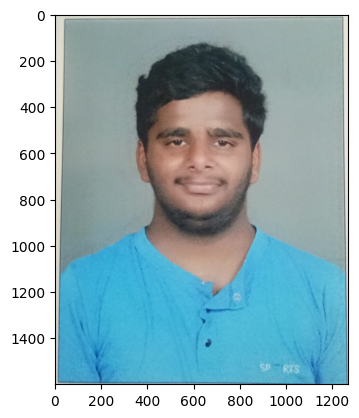

The person in the application form and the person in front of the camera are not the same person.
Proctor allocated for candidate ID 1
Proctor Proctor 1 allocated for candidate ID 1
Exam started for candidate ID 1


In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2
import threading
import numpy as np
import random
import time

# Load the CSV files into DataFrames
candidates = pd.read_csv('candidate.csv')
proctors = pd.read_csv('Proctor.csv')
proctor_allocation_global = pd.read_csv('Proctor_alocation.csv')

available_proctors = {}
for index, row in proctors.iterrows():
    available_proctors[row['ProctorName']] = {"available": True, "candidate": None}

candidates_dict = {}
for index, row in candidates.iterrows():
    candidates_dict[row['CandidateName']] = {"allocated": False, "proctor": None}

def check_proctor_availability(proctor_id):
    """
    Check if a proctor is available
    """
    proctor_status = proctors.loc[proctors['ProctorID'] == proctor_id, 'Status'].values[0]
    return proctor_status == 'Available'

def allocate_proctor_to_candidate(candidate_id):
    """
    Allocate a proctor to a candidate
    """
    global proctor_allocation_global  # Access the global variable
    available_proctors_list = [proctor for proctor, status in available_proctors.items() if status["available"]]
    if available_proctors_list:
        proctor_name = available_proctors_list[0]
        proctor_id = proctors.loc[proctors['ProctorName'] == proctor_name, 'ProctorID'].values[0]
        new_allocation = pd.DataFrame({'AllocationID': [len(proctor_allocation_global) + 1], 'ProctorID': [proctor_id], 'CandidateID': [candidate_id], 'AllocationTimestamp': [pd.Timestamp.now()]})
        proctor_allocation_global = pd.concat([proctor_allocation_global, new_allocation], ignore_index=True)
        available_proctors[proctor_name]["available"] = False
        available_proctors[proctor_name]["candidate"] = candidate_id
        candidates.loc[candidates['CandidateID'] == candidate_id, 'Status'] = 'In Exam'
        return True
    else:
        return False

def start_exam(candidate_id):
    """
    Start the exam if a proctor is allocated
    """
    allocated_proctor = proctor_allocation_global.loc[proctor_allocation_global['CandidateID'] == candidate_id]
    if not allocated_proctor.empty:
        return True
    else:
        return False

def update_status_after_exam(candidate_id):
    """
    Update the status of proctor and candidate after the exam
    """
    global proctor_allocation_global  # Access the global variable
    allocated_proctor = proctor_allocation_global.loc[proctor_allocation_global['CandidateID'] == candidate_id]
    proctor_id = allocated_proctor['ProctorID'].values[0]
    proctor_name = proctors.loc[proctors['ProctorID'] == proctor_id, 'ProctorName'].values[0]
    available_proctors[proctor_name]["available"] = True
    available_proctors[proctor_name]["candidate"] = None
    candidates.loc[candidates['CandidateID'] == candidate_id, 'Status'] = 'Completed'

def display_webcam_feed(candidate_id):
    """
    Display the webcam feed for a candidate
    """
    cap = cv2.VideoCapture(0)
    while True:
        ret, frame = cap.read()
        cv2.imshow(f'Webcam Feed - {candidate_id}', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

def authenticate_candidate():
    """
    Authenticate the candidate using their ID and password
    """
    candidate_id = int(input("Enter candidate ID: "))
    password = input("Enter password: ")
    if 'Password' in candidates.columns:  # Check if 'Password' column exists
        if candidate_id in candidates['CandidateID'].values and password == candidates.loc[candidates['CandidateID'] == candidate_id, 'Password'].values[0]:
            return candidate_id
        else:
            print("Invalid candidate ID or password")
            return None
    else:
        print("Password column does not exist in the candidates CSV file")
        return None

def display_candidate_image(candidate_id):
    """
    Display the candidate's image
    """
    image_file_path = candidates.loc[candidates['CandidateID'] == candidate_id, 'images'].values[0]
    if os.path.exists(image_file_path):
        print(f"Found image for candidate {candidate_id}: {image_file_path}")
        img = plt.imread(image_file_path)
        plt.imshow(img)
        plt.show()
    else:
        print(f"Error: Image file not found for candidate {candidate_id}: {image_file_path}")

def verify_candidate_image(candidate_id):
    """
    Verify the candidate's image
    """
    pwd_image_path = '1234.jpg'
    pwd_image = cv2.imread(pwd_image_path)

    camera = cv2.VideoCapture(0)

    while True:
        ret, camera_image = camera.read()

        camera_image_resized = cv2.resize(camera_image, (pwd_image.shape[1], pwd_image.shape[0]))

        pwd_image_gray = cv2.cvtColor(pwd_image, cv2.COLOR_BGR2GRAY)
        camera_image_gray = cv2.cvtColor(camera_image_resized, cv2.COLOR_BGR2GRAY)

        # Calculate the absolute difference between the images
        diff = cv2.absdiff(pwd_image_gray, camera_image_gray)

        # Calculate the percentage of pixels that are different
        diff_percentage = np.sum(diff) / (pwd_image_gray.shape[0] * pwd_image_gray.shape[1])

        # Check if the difference percentage is below the threshold
        if diff_percentage < 75.0:
            print("The person in the application form and the person in front of the camera are the same person.")
        else:
            print("The person in the application form and the person in front of the camera are not the same person.")

        cv2.imshow('Camera', camera_image)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    camera.release()
    cv2.destroyAllWindows()

def main():
    candidate_id = authenticate_candidate()
    if candidate_id:
        display_candidate_image(candidate_id)
        verify_candidate_image(candidate_id)
        if allocate_proctor_to_candidate(candidate_id):
            print("Proctor allocated for candidate ID", candidate_id)
            allocated_proctor = proctor_allocation_global.loc[proctor_allocation_global['CandidateID'] == candidate_id]
            proctor_id = allocated_proctor['ProctorID'].values[0]
            proctor_name = proctors.loc[proctors['ProctorID'] == proctor_id, 'ProctorName'].values[0]
            print("Proctor", proctor_name, "allocated for candidate ID", candidate_id)
            if start_exam(candidate_id):
                print("Exam started for candidate ID", candidate_id)
                # Start the webcam feed in a separate thread
                threading.Thread(target=display_webcam_feed, args=(candidate_id,)).start()
                # Exam logic here
                update_status_after_exam(candidate_id)
            else:
                print("Waiting for proctor to be assigned for candidate ID", candidate_id)
        else:
            print("Authentication failed")

if __name__ == "__main__":
    main()

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2
import threading
import numpy as np
import random
import time
import face_recognition

# Load the CSV files into DataFrames
candidates = pd.read_csv('candidate.csv')
proctors = pd.read_csv('Proctor.csv')
proctor_allocation_global = pd.read_csv('Proctor_alocation.csv')

available_proctors = {}
for index, row in proctors.iterrows():
    available_proctors[row['ProctorName']] = {"available": True, "candidate": None}

candidates_dict = {}
for index, row in candidates.iterrows():
    candidates_dict[row['CandidateName']] = {"allocated": False, "proctor": None}

def check_proctor_availability(proctor_id):
    """
    Check if a proctor is available
    """
    proctor_status = proctors.loc[proctors['ProctorID'] == proctor_id, 'Status'].values[0]
    return proctor_status == 'Available'

def allocate_proctor_to_candidate(candidate_id):
    """
    Allocate a proctor to a candidate
    """
    global proctor_allocation_global  # Access the global variable
    available_proctors_list = [proctor for proctor, status in available_proctors.items() if status["available"]]
    if available_proctors_list:
        proctor_name = available_proctors_list[0]
        proctor_id = proctors.loc[proctors['ProctorName'] == proctor_name, 'ProctorID'].values[0]
        new_allocation = pd.DataFrame({'AllocationID': [len(proctor_allocation_global) + 1], 'ProctorID': [proctor_id], 'CandidateID': [candidate_id], 'AllocationTimestamp': [pd.Timestamp.now()]})
        proctor_allocation_global = pd.concat([proctor_allocation_global, new_allocation], ignore_index=True)
        available_proctors[proctor_name]["available"] = False
        available_proctors[proctor_name]["candidate"] = candidate_id
        candidates.loc[candidates['CandidateID'] == candidate_id, 'Status'] = 'In Exam'
        return True
    else:
        return False

def start_exam(candidate_id):
    """
    Start the exam if a proctor is allocated
    """
    allocated_proctor = proctor_allocation_global.loc[proctor_allocation_global['CandidateID'] == candidate_id]
    if not allocated_proctor.empty:
        return True
    else:
        return False

def update_status_after_exam(candidate_id):
    """
    Update the status of proctor and candidate after the exam
    """
    global proctor_allocation_global  # Access the global variable
    allocated_proctor = proctor_allocation_global.loc[proctor_allocation_global['CandidateID'] == candidate_id]
    proctor_id = allocated_proctor['ProctorID'].values[0]
    proctor_name = proctors.loc[proctors['ProctorID'] == proctor_id, 'ProctorName'].values[0]
    available_proctors[proctor_name]["available"] = True
    available_proctors[proctor_name]["candidate"] = None
    candidates.loc[candidates['CandidateID'] == candidate_id, 'Status'] = 'Completed'

def display_webcam_feed(candidate_id):
    """
    Display the webcam feed for a candidate
    """
    cap = cv2.VideoCapture(0)
    while True:
        ret, frame = cap.read()
        cv2.imshow(f'Webcam Feed - {candidate_id}', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

def display_webcam_feed_2(candidate_id):
    """
    Display the webcam feed 2 for a candidate
    """
    cap = cv2.VideoCapture(1)
    while True:
        ret, frame = cap.read()
        cv2.imshow(f'Webcam Feed 2 - {candidate_id}', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

def authenticate_candidate():
    """
    Authenticate the candidate using their ID and password
    """
    candidate_id = int(input("Enter candidate ID: "))
    password = input("Enter password: ")
    if 'Password' in candidates.columns:  # Check if 'Password' column exists
        if candidate_id in candidates['CandidateID'].values and password == candidates.loc[candidates['CandidateID'] == candidate_id, 'Password'].values[0]:
            return candidate_id
        else:
            print("Invalid candidate ID or password")
            return None
    else:
        print("Password column does not exist in the candidates CSV file")
        return None

def display_candidate_image(candidate_id):
    """
    Display the candidate's image
    """
    image_file_path = candidates.loc[candidates['CandidateID'] == candidate_id, 'images'].values[0]
    if os.path.exists(image_file_path):
        print(f"Found image for candidate {candidate_id}: {image_file_path}")
        img = plt.imread(image_file_path)
        plt.imshow(img)
        plt.show()
    else:
        print(f"Error: Image file not found for candidate {candidate_id}: {image_file_path}")

def verify_candidate_image(candidate_id):
    """
    Verify the candidate's image
    """
    image_file_path = candidates.loc[candidates['CandidateID'] == candidate_id, 'images'].values[0]
    if os.path.exists(image_file_path):
        known_image = face_recognition.load_image_file(image_file_path)
        known_face_encoding = face_recognition.face_encodings(known_image)[0]

        cap = cv2.VideoCapture(0)
        match_count = 0
        start_time = time.time()
        while True:
            ret, frame = cap.read()
            rgb_frame = frame[:, :, ::-1]
            face_locations = face_recognition.face_locations(rgb_frame)
            face_encodings = face_recognition.face_encodings(rgb_frame, face_locations)

            for face_encoding in face_encodings:
                matches = face_recognition.compare_faces([known_face_encoding], face_encoding)
                if True in matches:
                    match_count += 1
                else:
                    match_count = 0

            if match_count >= 10:
                print("The person in the application form and the person in front of the camera are the same person.")
                threading.Thread(target=display_webcam_feed_2, args=(candidate_id,)).start()
                break
            elif time.time() - start_time > 10:
                print("The person in the application form and the person in front of the camera are not the same person.")
                update_status_after_exam(candidate_id)
                break

            cv2.imshow('Camera', frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

        cap.release()
        cv2.destroyAllWindows()
    else:
        print(f"Error: Image file not found for candidate {candidate_id}: {image_file_path}")

def main():
    candidate_id = authenticate_candidate()
    if candidate_id:
        display_candidate_image(candidate_id)
        verify_candidate_image(candidate_id)
        if allocate_proctor_to_candidate(candidate_id):
            print("Proctor allocated for candidate ID", candidate_id)
            allocated_proctor = proctor_allocation_global.loc[proctor_allocation_global['CandidateID'] == candidate_id]
            proctor_id = allocated_proctor['ProctorID'].values[0]
            proctor_name = proctors.loc[proctors['ProctorID'] == proctor_id, 'ProctorName'].values[0]
            print("Proctor", proctor_name, "allocated for candidate ID", candidate_id)
            if start_exam(candidate_id):
                print("Exam started for candidate ID", candidate_id)
                # Start the webcam feed in a separate thread
                threading.Thread(target=display_webcam_feed, args=(candidate_id,)).start()
                # Exam logic here
            else:
                print("Waiting for proctor to be assigned for candidate ID", candidate_id)
        else:
            print("Authentication failed")

if __name__ == "__main__":
    main()

AttributeError: module 'dlib' has no attribute 'get_frontal_face_detector'